<a href="https://colab.research.google.com/github/emilheroyt/Bachelor-Thesis-Stress-Testing-Robustness-of-SOTA-Point-Trackers/blob/main/Cotracker3Isolation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

GPU Test

In [2]:
!nvidia-smi

Thu Sep  3 20:45:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P0             49W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

Zelle 1- Dependencies installieren:

In [3]:
!pip install imageio[ffmpeg] opencv-python matplotlib einops timm moviepy -q

Zelle 2 – Testvideo laden (das mitgelieferte Beispielvideo aus dem Repo):

In [4]:
import torch
import imageio.v3 as iio

url = 'https://github.com/facebookresearch/co-tracker/raw/refs/heads/main/assets/apple.mp4'
frames = iio.imread(url, plugin="FFMPEG")

device = 'cuda'
video = torch.tensor(frames).permute(0, 3, 1, 2)[None].float().to(device)  # Form: B T C H W
print(video.shape)  # sollte sowas wie [1, ~30-60, 3, Höhe, Breite] zeigen

torch.Size([1, 50, 3, 720, 1296])


Motion Blur Funktion

In [5]:
import numpy as np

def apply_motion_blur(frames, center_idx, window_size, gamma=2.2):
    half = window_size // 2
    start = max(0, center_idx - half)
    end = min(len(frames), center_idx + half + 1)
    window = frames[start:end].astype(np.float32) / 255.0
    linear = window ** gamma
    linear_avg = linear.mean(axis=0)
    blurred = linear_avg ** (1.0 / gamma)
    return (blurred * 255).astype(np.uint8)

def blur_video(frames, window_size):
    return np.stack([apply_motion_blur(frames, i, window_size) for i in range(len(frames))])

BLUR_LEVELS = {"none": 1, "medium": 3, "strong": 7}

Zelle 3 – Modell laden und Inferenz laufen lassen:

In [6]:
cotracker = torch.hub.load("facebookresearch/co-tracker", "cotracker3_offline").to(device)

results = {}
for level_name, window in BLUR_LEVELS.items():
    blurred_frames = blur_video(frames, window)  # frames = deine Original-Frames aus Zelle 2
    video_blurred = torch.tensor(blurred_frames).permute(0, 3, 1, 2)[None].float().to(device)

    pred_tracks, pred_visibility = cotracker(video_blurred, grid_size=10)
    results[level_name] = (pred_tracks, pred_visibility, video_blurred)
    print(level_name, pred_tracks.shape)

Downloading: "https://github.com/facebookresearch/co-tracker/zipball/main" to /root/.cache/torch/hub/main.zip
Downloading: "https://huggingface.co/facebook/cotracker3/resolve/main/scaled_offline.pth" to /root/.cache/torch/hub/checkpoints/scaled_offline.pth


100%|██████████| 97.2M/97.2M [00:01<00:00, 73.7MB/s]


none torch.Size([1, 50, 100, 2])
medium torch.Size([1, 50, 100, 2])
strong torch.Size([1, 50, 100, 2])


Zelle 4 – Ergebnis visualisieren (der eigentliche Test, ob's funktioniert hat):

In [7]:
from cotracker.utils.visualizer import Visualizer

for level_name, (pred_tracks, pred_visibility, video_blurred) in results.items():
    vis = Visualizer(save_dir="./saved_videos", pad_value=120, linewidth=3)
    vis.visualize(video_blurred, pred_tracks, pred_visibility, filename=f"blur_{level_name}")

Video saved to ./saved_videos/blur_none.mp4
Video saved to ./saved_videos/blur_medium.mp4
Video saved to ./saved_videos/blur_strong.mp4


Direkt im Notebook anzeigen (am einfachsten):

In [8]:
import glob
print(glob.glob("./saved_videos/*.mp4"))  # zeigt dir den genauen Dateinamen

['./saved_videos/blur_strong.mp4', './saved_videos/blur_medium.mp4', './saved_videos/blur_none.mp4']


Irelevant Test

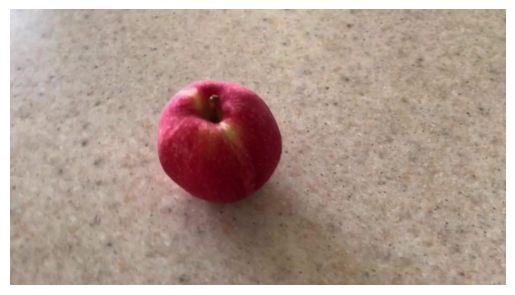

In [9]:
import matplotlib.pyplot as plt
plt.imshow(frames[15])
plt.axis("off")
plt.show()

Dann mit dem gefundenen Pfad:

In [10]:
from IPython.display import Video, display

for level_name in ["none", "medium", "strong"]:
    print(f"--- {level_name} ---")
    display(Video(f"./saved_videos/blur_{level_name}.mp4", embed=True))

--- none ---


--- medium ---


--- strong ---


Zelle 1 – Dependencies:

In [11]:
!pip install imageio[ffmpeg] opencv-python matplotlib einops timm moviepy -q

Zelle 2 – CoTracker3-Checkpoint + TAP-Vid-DAVIS + Eval-Utility:

In [12]:
!mkdir -p cotracker_checkpoints
!wget -q -P cotracker_checkpoints https://huggingface.co/facebook/cotracker3/resolve/main/scaled_offline.pth

!wget https://storage.googleapis.com/dm-tapnet/tapvid_davis.zip
!unzip -q -o tapvid_davis.zip

!pip install -q chex einshape dm-haiku optax tensorflow-cpu mediapy
!wget -q https://raw.githubusercontent.com/google-deepmind/tapnet/refs/heads/main/tapnet/tapvid/evaluation_datasets.py

--2026-09-03 20:46:21--  https://storage.googleapis.com/dm-tapnet/tapvid_davis.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.69.207, 64.233.181.207, 142.251.184.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.69.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1668710491 (1.6G) [application/zip]
Saving to: ‘tapvid_davis.zip’

tapvid_davis.zip    100%[===================>]   1.55G   179MB/s    in 11s     

2026-09-03 20:46:32 (150 MB/s) - ‘tapvid_davis.zip’ saved [1668710491/1668710491]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.3/102.3 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.0/377.0 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.3/274.3 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 83.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━

Zelle 3 – Eval-Funktionen importieren:


In [13]:
!pip install "tapnet[torch] @ git+https://github.com/google-deepmind/tapnet.git" -q

import sys
from unittest.mock import MagicMock

sys.modules['tensorflow'] = MagicMock()
sys.modules['tensorflow_datasets'] = MagicMock()
sys.modules['tensorflow'].io.gfile.GFile = open

sys.path.insert(0, '.')
import evaluation_datasets
from evaluation_datasets import create_davis_dataset, compute_tapvid_metrics
import numpy as np

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 519.0/519.0 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 8.5 MB/s eta 0:00:00


Zelle 4 – Modell laden (das CoTracker3-Repo selbst brauchst du auch noch für CoTrackerPredictor):

In [14]:
!git clone https://github.com/facebookresearch/co-tracker.git
%cd co-tracker
!pip install -e . -q
%cd ..

import sys
sys.path.insert(0, './co-tracker')

import torch
from cotracker.predictor import CoTrackerPredictor

model = CoTrackerPredictor(
    checkpoint='cotracker_checkpoints/scaled_offline.pth',
    offline=True,
    window_len=60
).cuda()
model.support_grid_size = 5

Cloning into 'co-tracker'...
remote: Enumerating objects: 451, done.
remote: Counting objects: 100% (274/274), done.
remote: Compressing objects: 100% (137/137), done.
remote: Total 451 (delta 205), reused 137 (delta 137), pack-reused 177 (from 3)
Receiving objects: 100% (451/451), 64.52 MiB | 44.28 MiB/s, done.
Resolving deltas: 100% (245/245), done.
/content/co-tracker
  Preparing metadata (setup.py) ... done
/content


Blur Funktionen:

In [15]:
def apply_motion_blur(frames, center_idx, window_size, gamma=2.2):
    half = window_size // 2
    start = max(0, center_idx - half)
    end = min(len(frames), center_idx + half + 1)
    window = frames[start:end].astype(np.float32) / 255.0
    linear = window ** gamma
    linear_avg = linear.mean(axis=0)
    blurred = linear_avg ** (1.0 / gamma)
    return (blurred * 255).astype(np.uint8)

def blur_video(frames, window_size):
    return np.stack([apply_motion_blur(frames, i, window_size) for i in range(len(frames))])

BLUR_LEVELS = {"none": 1, "medium": 3, "strong": 7}

Drive mounten:

In [16]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs('/content/drive/MyDrive/ba_results', exist_ok=True)

Mounted at /content/drive


Vollständiger Durchlauf über alle 30 Videos:

In [17]:
import pandas as pd

results_path = "/content/drive/MyDrive/ba_results/cotracker3_all_videos.csv"
all_results = []

davis = create_davis_dataset('tapvid_davis/tapvid_davis.pkl', query_mode='first')

for video_idx, sample in enumerate(davis):
    batch = sample['davis']
    raw_video = batch['video']
    query_points = batch['query_points']
    target_points = batch['target_points']
    occluded = batch['occluded']

    frames_raw = raw_video[0]
    frames_uint8 = frames_raw.astype(np.uint8) if frames_raw.max() > 1 else ((frames_raw + 1) / 2 * 255).astype(np.uint8)

    for level_name, window in BLUR_LEVELS.items():
        blurred = blur_video(frames_uint8, window)
        vid_tensor = torch.from_numpy(blurred[None]).permute(0, 1, 4, 2, 3).cuda().float()
        qp_tensor = torch.from_numpy(query_points).cuda().float()
        qp_tensor = torch.stack([qp_tensor[..., 0], qp_tensor[..., 2], qp_tensor[..., 1]], axis=2)

        pred_tracks, pred_visibility = model(vid_tensor, queries=qp_tensor)

        metrics = compute_tapvid_metrics(
            query_points, occluded, target_points,
            (~pred_visibility).transpose(1, 2).cpu().numpy(),
            pred_tracks.cpu().transpose(1, 2).numpy(),
            query_mode='first'
        )
        row = {"video": video_idx, "model": "CoTracker3", "blur": level_name}
        row.update({k: float(v.item()) * 100 for k, v in metrics.items()})
        all_results.append(row)

    pd.DataFrame(all_results).to_csv(results_path, index=False)
    print(f"Video {video_idx}/29 fertig")

print("Alle 30 Videos abgeschlossen.")
df = pd.DataFrame(all_results)
print(df.groupby("blur")[["average_jaccard", "occlusion_accuracy", "average_pts_within_thresh"]].mean())

Video 0/29 fertig
Video 1/29 fertig
Video 2/29 fertig
Video 3/29 fertig
Video 4/29 fertig
Video 5/29 fertig
Video 6/29 fertig
Video 7/29 fertig
Video 8/29 fertig
Video 9/29 fertig
Video 10/29 fertig
Video 11/29 fertig
Video 12/29 fertig
Video 13/29 fertig
Video 14/29 fertig
Video 15/29 fertig
Video 16/29 fertig
Video 17/29 fertig
Video 18/29 fertig
Video 19/29 fertig
Video 20/29 fertig
Video 21/29 fertig
Video 22/29 fertig
Video 23/29 fertig
Video 24/29 fertig
Video 25/29 fertig
Video 26/29 fertig
Video 27/29 fertig
Video 28/29 fertig
Video 29/29 fertig
Alle 30 Videos abgeschlossen.
        average_jaccard  occlusion_accuracy  average_pts_within_thresh
blur                                                                  
medium        46.862323           80.375335                  63.598239
none          62.563783           88.130537                  77.193544
strong        25.950106           66.902586                  41.592528


Video 1 gezielt neu laden:

In [20]:
davis_v1 = create_davis_dataset('tapvid_davis/tapvid_davis.pkl', query_mode='first')
for i, sample in enumerate(davis_v1):
    if i == 1:
        batch = sample['davis']
        break

query_points = batch['query_points']
raw_video = batch['video']
frames_raw = raw_video[0]
frames_uint8 = frames_raw.astype(np.uint8) if frames_raw.max() > 1 else ((frames_raw + 1) / 2 * 255).astype(np.uint8)

Trajektorien für Video 1 (strong blur) speichern:

In [21]:
level_name, window = "strong", BLUR_LEVELS["strong"]
blurred = blur_video(frames_uint8, window)
vid_tensor = torch.from_numpy(blurred[None]).permute(0, 1, 4, 2, 3).cuda().float()
qp_tensor = torch.from_numpy(query_points).cuda().float()
qp_tensor = torch.stack([qp_tensor[..., 0], qp_tensor[..., 2], qp_tensor[..., 1]], axis=2)

pred_tracks, pred_visibility = model(vid_tensor, queries=qp_tensor)

import numpy as np
np.save("/content/drive/MyDrive/ba_results/cotracker3_traj_video1_strong.npy",
        pred_tracks.cpu().numpy()[0].transpose(1, 0, 2))